# NumPy a obrázky v Pythonu



NumPy je knihovna pro práci s numerickými poli.

Základ knihovny NumPy je pole:
- jeden souvislý kus paměti
- všechny prvky mají stejný datový typ

Python `list` neobsahuje čísla, ale ukazatele na objekty a to `list` činí pomalejčí, je pamě´tově náročnější a každý prvek může být jiný.

```python
import numpy as np
a = np.array([1, 2, 3])
```

`[a] → [1][2][3]`

- hodnoty jsou uložené vedle sebe
- žádné ukazatele na Python objekty
- pevný typ (např. int64)

Vektorové operace se provádí nad celým polem ane prvek po prvku:

```python
a = np.array([1, 2, 3])
a = a + 10
```

Černobílý obrázek = 2D pole čísel

Barevný obrázek = 3D pole čísel

Např.:

- grayscale: (výška, šířka)
- RGB: (výška, šířka, 3)

Každý pixel je číslo nebo trojice čísel:

- R = červená
- G = zelená
- B = modrá

Co budeme potřebovat?

```
pip install pillow matplotlib numpy
```

[[  0  50 100 150 200]
 [ 20  70 120 170 220]
 [ 40  90 140 190 240]
 [ 60 110 160 210 255]
 [ 80 130 180 230 255]]


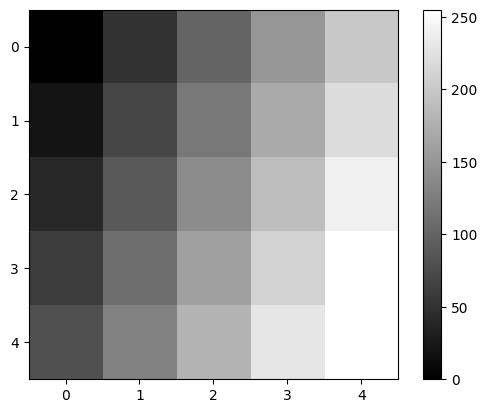

In [1]:
import numpy as np              
import matplotlib.pyplot as plt  # knihovna pro vizualizaci (vykreslování grafů a obrázků)

# Vytvoření 2D NumPy pole (matice), které budeme interpretovat jako obrázek
# Každá hodnota reprezentuje jas pixelu (0 = černá, 255 = bílá)
img = np.array([
    [0, 50, 100, 150, 200],
    [20, 70, 120, 170, 220],
    [40, 90, 140, 190, 240],
    [60, 110, 160, 210, 255],
    [80, 130, 180, 230, 255]
], dtype=np.uint8)  # uint8 = celé číslo 0–255 (standardní typ pro obrázky)

# Výpis pole do konzole
# Umožňuje vidět „číselnou reprezentaci obrázku“
print(img)

# Zobrazení pole jako obrázku
# imshow interpretuje 2D pole jako grayscale obrázek
plt.imshow(img, cmap="gray")

# cmap="gray" říká:
# - nízké hodnoty → tmavé (černá)
# - vysoké hodnoty → světlé (bílá)

# Přidání barevné škály (legendy)
# Ukazuje mapování mezi hodnotami (0–255) a barvou
plt.colorbar()

# Vykreslení výsledku do okna
plt.show()

Změna hodnot pixelů pomocí indexů, například na indexu `[0, 0]` (vlevo nahoře), nebo `[4, 4]` (vpravo dole):

In [ ]:
img2 = img.copy()
img2[0, 0] = 255
img2[4, 4] = 0

plt.imshow(img2, cmap="gray")
plt.show()

Vytvoření dvou čar pomocí slicingu `[:]`

In [ ]:
img3 = img.copy()
img3[2, :] = 255      # celý prostřední řádek
img3[:, 2] = 255      # celý prostřední sloupec

plt.imshow(img3, cmap="gray")
plt.show()

Tvorba šachovnice:

In [ ]:
board = np.zeros((8, 8), dtype=np.uint8)

for i in range(8):
    for j in range(8):
        if (i + j) % 2 == 0:
            board[i, j] = 255

plt.imshow(board, cmap="gray")
plt.show()

Načtení skutečného obrázku:

(183, 275, 3)
uint8


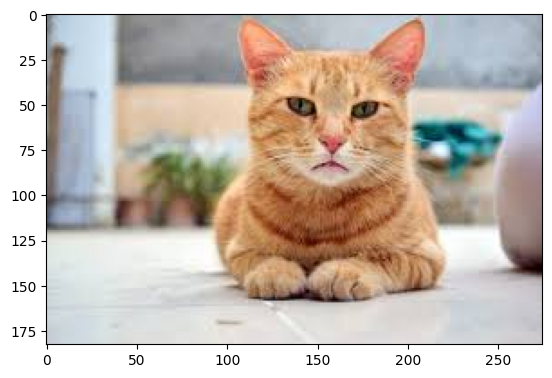

In [4]:
from PIL import Image          # knihovna Pillow pro práci s obrázky (načítání, ukládání)
import numpy as np             
import matplotlib.pyplot as plt  

# Načtení obrázku ze souboru
# Výsledkem je objekt typu PIL.Image (není to ještě NumPy pole)
image = Image.open("obrazek.jpeg")

# Převod obrázku na NumPy pole (ndarray)
# Každý pixel se převede na čísla:
# - grayscale → jedno číslo
# - RGB → trojice čísel (R, G, B)
img = np.array(image)

# Výpis tvaru pole (shape)
# Typicky: (výška, šířka, 3) pro barevný obrázek
# Např. (400, 600, 3) znamená:
# - 400 řádků (výška)
# - 600 sloupců (šířka)
# - 3 barevné kanály (RGB)
print(img.shape)

# Výpis datového typu
# Nejčastěji uint8 (hodnoty 0–255)
# To odpovídá standardní reprezentaci pixelů
print(img.dtype)

# Zobrazení obrázku
# matplotlib rozpozná, že jde o RGB obrázek (3D pole)
plt.imshow(img)

# Vykreslení do okna
plt.show()

Zobrazení jen červeného kanálu:

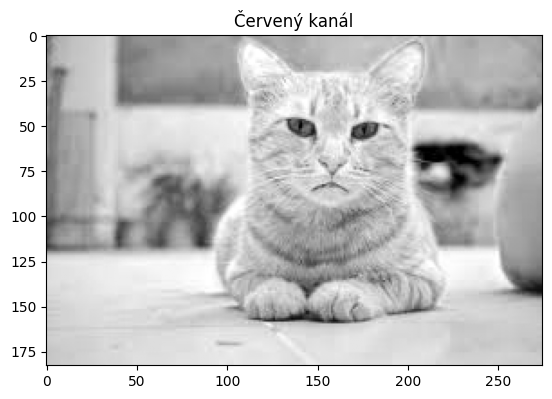

In [5]:
# Výběr červeného kanálu z RGB obrázku
# img má typicky tvar (výška, šířka, 3)
# poslední index (0, 1, 2) odpovídá barvám:
# 0 = red, 1 = green, 2 = blue
red = img[:, :, 0]


# Výsledkem je 2D pole (výška × šířka),
# tedy grayscale reprezentace intenzity červené barvy

# Zobrazení výsledného pole jako obrázku
plt.imshow(red, cmap="gray")

# cmap="gray" říká:
# - nízká hodnota → tmavá (málo červené)
# - vysoká hodnota → světlá (hodně červené)

# Přidání titulku obrázku
plt.title("Červený kanál")

# Vykreslení obrázku
plt.show()

Odstranění Modré složky

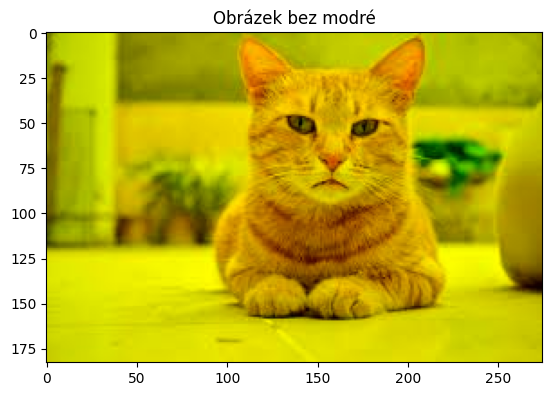

In [6]:
img_no_blue = img.copy()
img_no_blue[:, :, 2] = 0

plt.imshow(img_no_blue)
plt.title("Obrázek bez modré")
plt.show()

Pouze zelená:

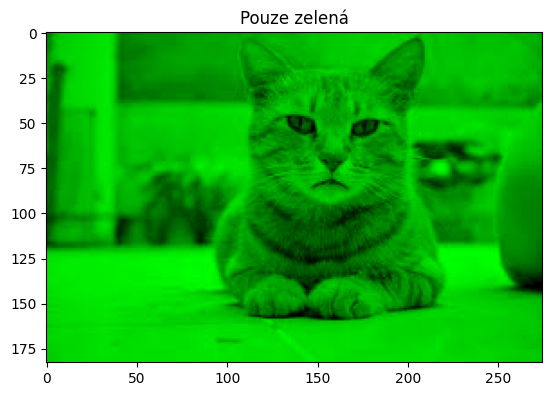

In [7]:
green_only = img.copy()
green_only[:, :, 0] = 0
green_only[:, :, 2] = 0

plt.imshow(green_only)
plt.title("Pouze zelená")
plt.show()

Zesvětlení a ztmavení:

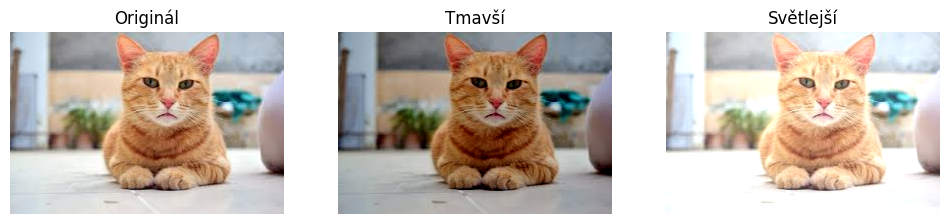

In [9]:
# Zvýšení jasu (zesvětlení obrázku)
# Postup:
# 1. převedeme data na větší typ (int16), aby nedošlo k přetečení
# 2. přičteme konstantu (50)
# 3. omezíme hodnoty na interval 0–255 pomocí np.clip
# 4. vrátíme zpět na uint8 (standard pro obrázky)
lighter = np.clip(img.astype(np.int16) + 50, 0, 255).astype(np.uint8)

# Snížení jasu (ztmavení obrázku)
# stejný princip, ale hodnoty odečítáme
darker = np.clip(img.astype(np.int16) - 50, 0, 255).astype(np.uint8)

# Vytvoření nové "plochy" pro více obrázků vedle sebe
# figsize určuje velikost okna (šířka, výška)
plt.figure(figsize=(12,4))

# subplot(1,3,1) znamená:
# - 1 řádek
# - 3 sloupce
# - první pozice
plt.subplot(1,3,1)
plt.imshow(img)              # původní obrázek
plt.title("Originál")        # titulek
plt.axis("off")              # vypne osy (nejsou potřeba u obrázků)

# Druhý obrázek – zesvětlený
plt.subplot(1,3,3)
plt.imshow(lighter)
plt.title("Světlejší")
plt.axis("off")

# Třetí obrázek – ztmavený
plt.subplot(1,3,2)
plt.imshow(darker)
plt.title("Tmavší")
plt.axis("off")

# Vykreslení celé kompozice
plt.show()

Negativ obrázku

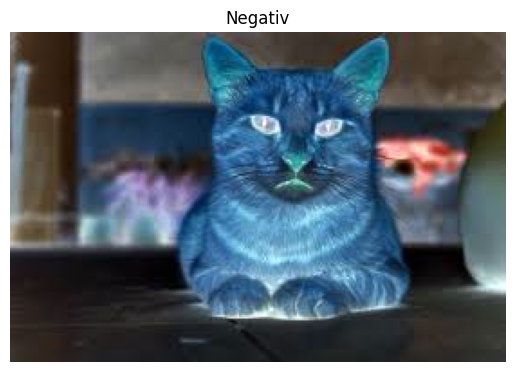

In [10]:
# Každý pixel (resp. každá barevná složka) se transformuje podle vzorce:
# nová_hodnota = 255 - původní_hodnota
#
# Příklady:
# 0   → 255   (černá → bílá)
# 255 → 0     (bílá → černá)
# 100 → 155   (střední jas → opačný jas)

negative = 255 - img

plt.imshow(negative)
plt.title("Negativ")
plt.axis("off")
plt.show()

Oříznutí obrázku

In [ ]:
crop = img[50:250, 100:300]

plt.imshow(crop)
plt.title("Oříznutý obrázek")
plt.axis("off")
plt.show()

Převrácení:

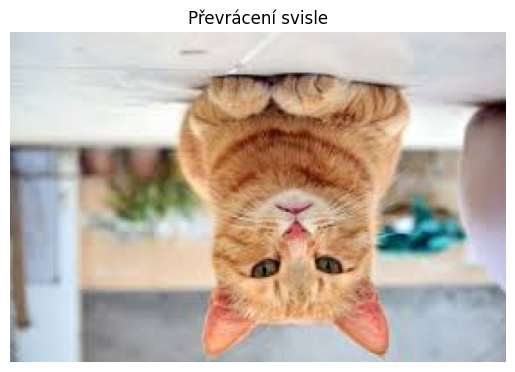

In [11]:
#img má typicky tvar (výška, šířka, 3)

# img[::-1, :, :] znamená:
# - první osa (řádky / výška): [::-1]
#     → vezmi všechny řádky, ale v opačném pořadí
#     → krok -1 = jdi odzadu dopředu
#
# - druhá osa (sloupce / šířka): [:]
#     → vezmi všechny sloupce beze změny
#
# - třetí osa (barevné kanály): [:]
#     → ponech všechny barvy (RGB)

flip_v = img[::-1, :, :]
plt.imshow(flip_v)
plt.title("Převrácení svisle")
plt.axis("off")
plt.show()

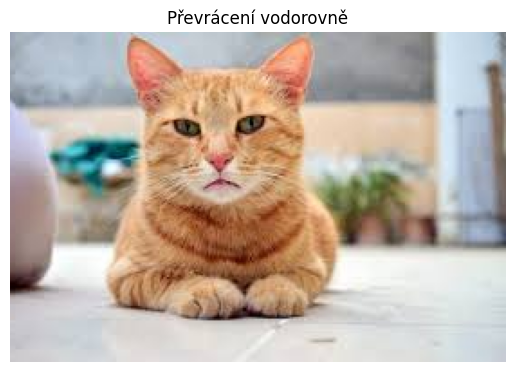

In [12]:
flip_h = img[:, ::-1, :]
plt.imshow(flip_h)
plt.title("Převrácení vodorovně")
plt.axis("off")
plt.show()